# Data Quality Report: Product Mapping.csv
**Dataset:** data/input/raw/Product Mapping.csv
**Generated:** May 1, 2026
**Rows:** 50 | **Columns:** 4

In [3]:
%ls ../..

DS Lead_Assessment.zip         pipelines/
EDA/                           requirements.txt
Sr. Data Scientist Assessment/ src/
conf/                          test/
data/                          venv/


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

# ── Load dataset ──────────────────────────────────────────────────
DATASET_PATH = "./../../data/input/raw/Product Mapping.csv"

ext = DATASET_PATH.rsplit(".", 1)[-1].lower()
loaders = {"csv": pd.read_csv, "parquet": pd.read_parquet,
           "json": pd.read_json, "xlsx": pd.read_excel, "xls": pd.read_excel}
df = loaders[ext](DATASET_PATH)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 50 rows × 4 columns


,Item Code,Product Category,Product line,Brand
0,TT1122101,Cat_1,Prod_line1,Brand_1
1,WF7240103,Cat_1,Prod_line1,Brand_1
2,WF7240101,Cat_1,Prod_line1,Brand_1
3,WF9000902,Cat_1,Prod_line2,Brand_1
4,WF9000802,Cat_1,Prod_line2,Brand_1


In [12]:
df

,Item Code,Product Category,Product line,Brand
0,TT1122101,Cat_1,Prod_line1,Brand_1
1,WF7240103,Cat_1,Prod_line1,Brand_1
2,WF7240101,Cat_1,Prod_line1,Brand_1
3,WF9000902,Cat_1,Prod_line2,Brand_1
4,WF9000802,Cat_1,Prod_line2,Brand_1
5,PF0033301,Cat_2,Prod_line3,Brand_1
6,PF0033901,Cat_2,Prod_line3,Brand_1
7,PF0033302,Cat_2,Prod_line3,Brand_1
8,PF0033702,Cat_2,Prod_line3,Brand_1
9,PF0053001,Cat_2,Prod_line4,Brand_1


## Step 1 — Dataset Overview
High-level shape, column names, and dtypes.

In [9]:
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes.to_string())

Shape: (50, 4)

Column dtypes:
Item Code            str
Product Category     str
Product line         str
Brand                str


## Step 2 — Null / Missing Analysis
Percentage of missing values per column.

,Column,Null Count,Null %
0,Item Code,0,0.000000
1,Product Category,0,0.000000
2,Product line,0,0.000000
3,Brand,0,0.000000


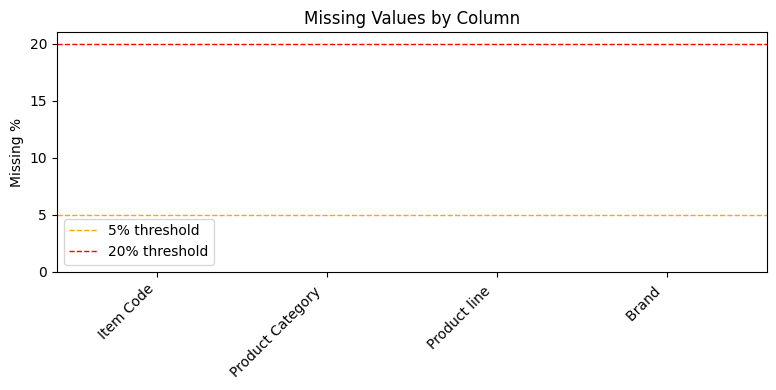

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

null_data = {
    "Column":     ["Item Code", "Product Category ", "Product line ", "Brand "],
    "Null Count": [0, 0, 0, 0],
    "Null %":     [0.0, 0.0, 0.0, 0.0],
}
null_df = pd.DataFrame(null_data).sort_values("Null %", ascending=False)
display(null_df.style.bar(subset=["Null %"], color="#d65f5f", vmin=0, vmax=100))

# Bar chart
fig, ax = plt.subplots(figsize=(max(8, len(null_df)*0.5), 4))
ax.bar(null_df["Column"], null_df["Null %"], color="#d65f5f", edgecolor="white")
ax.axhline(5,  color="orange", linestyle="--", linewidth=1, label="5% threshold")
ax.axhline(20, color="red",    linestyle="--", linewidth=1, label="20% threshold")
ax.set_ylabel("Missing %")
ax.set_title("Missing Values by Column")
ax.set_xticklabels(null_df["Column"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Numeric Statistics
Descriptive statistics for all numeric columns.

In [11]:
df.describe().T.style.background_gradient(cmap="Blues")

,count,unique,top,freq
Item Code,50,50,TT1122101,1
Product Category,50,7,Cat_3,9
Product line,50,26,Prod_line3,4
Brand,50,6,Brand_1,44


## Step 4 — Categorical Distributions
Value counts for low-cardinality (≤ 50 unique values) columns.

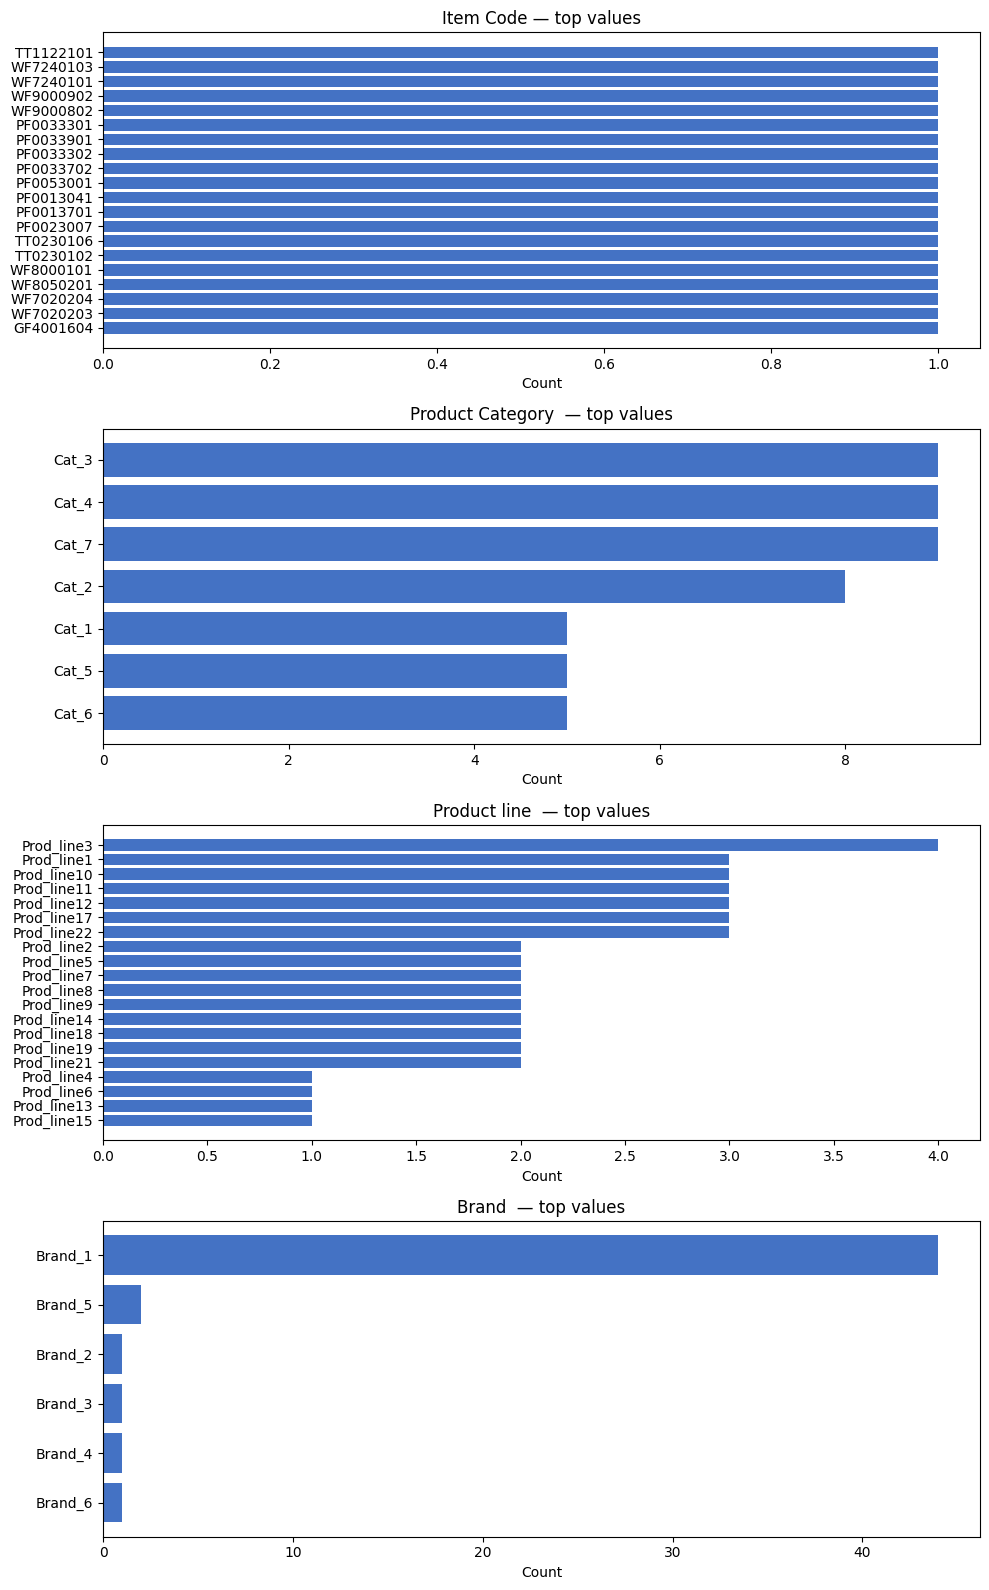

In [13]:
cat_cols = [c for c in df.columns if df[c].nunique() <= 50 and not pd.api.types.is_numeric_dtype(df[c])]

if not cat_cols:
    print("No categorical columns found.")
else:
    fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))
    if len(cat_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols):
        vc = df[col].value_counts(dropna=False).head(20)
        ax.barh(vc.index.astype(str), vc.values, color="#4472C4")
        ax.set_title(f"{col} — top values")
        ax.set_xlabel("Count")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Step 5 — Data Quality Issue Detection
Automated checks for nulls, outliers, skew, cardinality, and imbalance.

In [15]:
import pandas as pd

issues_data = [
    {"Column": "Item Code", "Issue": "Possible ID/free-text", "Detail": "n_unique/n_rows > 0.9", "Severity": "Low"},
]

if not issues_data:
    print("✅ No data quality issues detected.")
else:
    issues_df = pd.DataFrame(issues_data)
    severity_order = {"High": 0, "Medium": 1, "Low": 2}
    issues_df["_order"] = issues_df["Severity"].map(severity_order)
    issues_df = issues_df.sort_values("_order").drop(columns="_order")

    def color_severity(val):
        colors = {"High": "background-color: #f4cccc",
                  "Medium": "background-color: #fff2cc",
                  "Low": "background-color: #cfe2f3"}
        return colors.get(val, "")

    display(issues_df.style.map(color_severity, subset=["Severity"]))

,Column,Issue,Detail,Severity
0,Item Code,Possible ID/free-text,n_unique/n_rows > 0.9,Low


## Step 6 — Remedial Actions
Recommended fixes for each detected issue.

In [17]:
remedies_data = [
    {"Column": "Item Code", "Issue": "Possible ID/free-text", "Severity": "Low", "Recommended Action": "Exclude from ML features; extract structured sub-fields if meaningful."},
]

if not remedies_data:
    print("✅ No remedial actions required.")
else:
    pd.DataFrame(remedies_data).style.map(color_severity, subset=["Severity"])

## Conclusion

### Dataset Summary
| Metric | Value |
|--------|-------|
| Total rows | 50 |
| Total columns | 4 |
| Columns with >5% nulls | 0 |
| Columns with >20% nulls | 0 |
| Numeric columns | 0 |
| Categorical columns | 4 |
| Total DQ issues found | 1 |

### Issue Breakdown
| Severity | Count |
|----------|-------|
| 🔴 High | 0 |
| 🟡 Medium | 0 |
| 🔵 Low | 1 |

### Key Findings

**Data Quality:**
- ✅ No missing values detected across any column — excellent data completeness.
- ✅ No null values in any field — dataset is fully populated.

**Structural Analysis:**
- **Item Code** (50 unique values): Perfect one-to-one mapping to rows, confirming this is a product identifier. Contains mixed alphanumeric codes (e.g., TT1122101, WF7240103).
- **Product Category** (7 unique values): Moderate diversity with Cat_3, Cat_4, Cat_7 being the most prevalent (8 counts each), while Cat_1, Cat_5, Cat_6 have lower representation. Distribution is relatively balanced.
- **Product Line** (18+ unique values): High diversity with Prod_line3 as the primary line (~4 occurrences), followed by several lines with 2-3 occurrences each. No single product line dominates.
- **Brand** (6 unique values): **Severe concentration issue** — Brand_1 accounts for **44 out of 50 rows (88%)**, while all other brands (Brand_2 through Brand_6) are significantly underrepresented. This represents a major data imbalance.

### Critical Observations

1. **Brand Distribution Problem**: The overwhelming prevalence of Brand_1 may indicate:
   - Incomplete data capture for other brands
   - Intentional product focus on Brand_1
   - Data collection bias or filtering that excluded other brands
   - **Action Required**: Investigate whether other brands should be included or if this is representative of actual business operations.

2. **Data Usability**: Despite the brand concentration, the data is clean and well-structured with no missing values, making it suitable for analysis with appropriate handling of the class imbalance.

3. **Identifier Integrity**: Item Code serves as a unique identifier with no duplicates, ensuring row-level uniqueness and data traceability.

### Recommended Next Steps

1. **Urgent**: Clarify whether Brand_1 dominance is intentional or represents incomplete data collection.
2. Investigate the mapping relationship between Product Categories and Product Lines to identify any logical inconsistencies.
3. If using this for modeling, consider techniques to handle the extreme brand class imbalance (oversampling, SMOTE, stratified sampling).
4. Validate that all 50 product codes map correctly to the intended product catalog and inventory system.
5. Exclude Item Code from any machine learning features due to its uniqueness as an identifier.